# Applying Bayes' Rule in Python

In this notebook, we'll solve the following probability problem using Bayes' rule:

> The probability that it is Friday and that a student is absent is 3%. Since there are 5 school days in a week, the probability that it is Friday is 20%. What is the probability that a student is absent given that today is Friday?

In [2]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set up plotting style
plt.style.use('seaborn-darkgrid')
%matplotlib inline

OSError: 'seaborn-darkgrid' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)

## Understanding Bayes' Rule

Bayes' rule is a mathematical formula used for calculating conditional probability. It describes the probability of an event based on prior knowledge of conditions that might be related to the event.

The formula is:

$$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$$

Where:
- $P(A|B)$ is the probability of event A occurring given that B is true
- $P(B|A)$ is the probability of event B occurring given that A is true
- $P(A)$ is the probability of event A
- $P(B)$ is the probability of event B

Let's apply this to our problem.

## Problem Analysis

Given:
- $P(\text{Friday} \cap \text{Absent}) = 0.03$ (probability that it is Friday and student is absent)
- $P(\text{Friday}) = 0.20$ (probability that it is Friday)

We need to find:
- $P(\text{Absent} | \text{Friday})$ (probability that a student is absent given that today is Friday)

Using Bayes' rule:
$$P(\text{Absent} | \text{Friday}) = \frac{P(\text{Friday} \cap \text{Absent})}{P(\text{Friday})}$$

This is a direct application of the formula for conditional probability.

In [4]:
# Given information
p_friday_and_absent = 0.03  # P(Friday ∩ Absent)
p_friday = 0.20  # P(Friday)

# Calculate P(Absent | Friday) using Bayes' rule
p_absent_given_friday = p_friday_and_absent / p_friday

print(f"P(Absent | Friday) = {p_absent_given_friday:.4f} or {p_absent_given_friday * 100:.2f}%")

P(Absent | Friday) = 0.1500 or 15.00%


## Visual Representation of the Problem

Let's create a visual representation to better understand the problem.

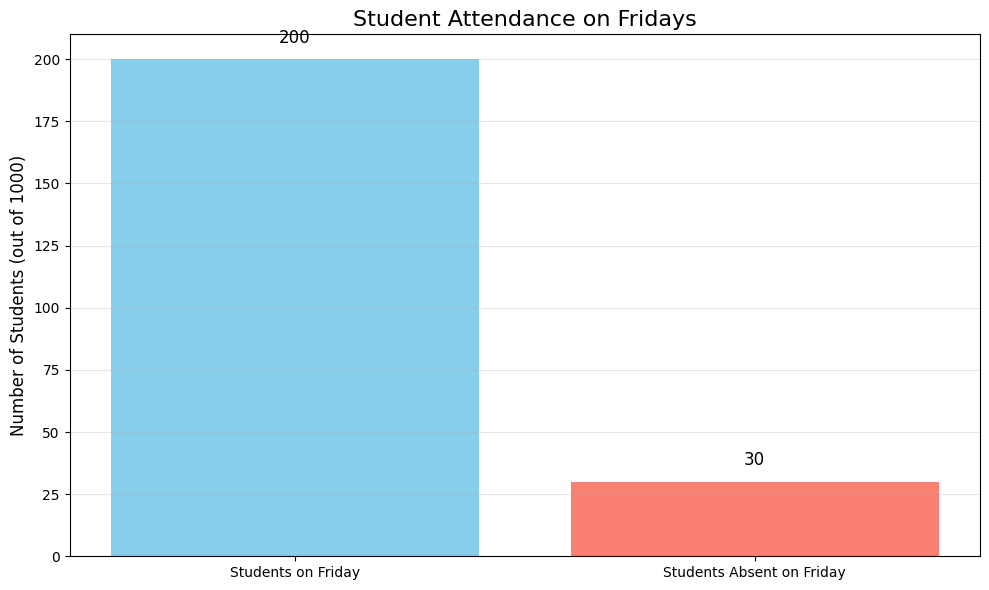

In [5]:
# Let's assume a total of 1000 students for visualization purposes
total_students = 1000

# Calculate counts based on probabilities
friday_count = total_students * p_friday  # 20% of all days are Fridays
friday_and_absent_count = total_students * p_friday_and_absent  # 3% of all days are both Friday and student is absent
absent_given_friday_count = friday_and_absent_count / (friday_count / total_students) * (friday_count / total_students)

# Create a dataframe for visualization
data = pd.DataFrame({
    'Category': ['Students on Friday', 'Students Absent on Friday'],
    'Count': [friday_count, friday_and_absent_count]
})

# Create bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(data['Category'], data['Count'], color=['skyblue', 'salmon'])
plt.title('Student Attendance on Fridays', fontsize=16)
plt.ylabel('Number of Students (out of 1000)', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Add annotations
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{height:.0f}',
             ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

## Visualizing the Conditional Probability

Let's create a more detailed visualization to better understand the conditional probability.

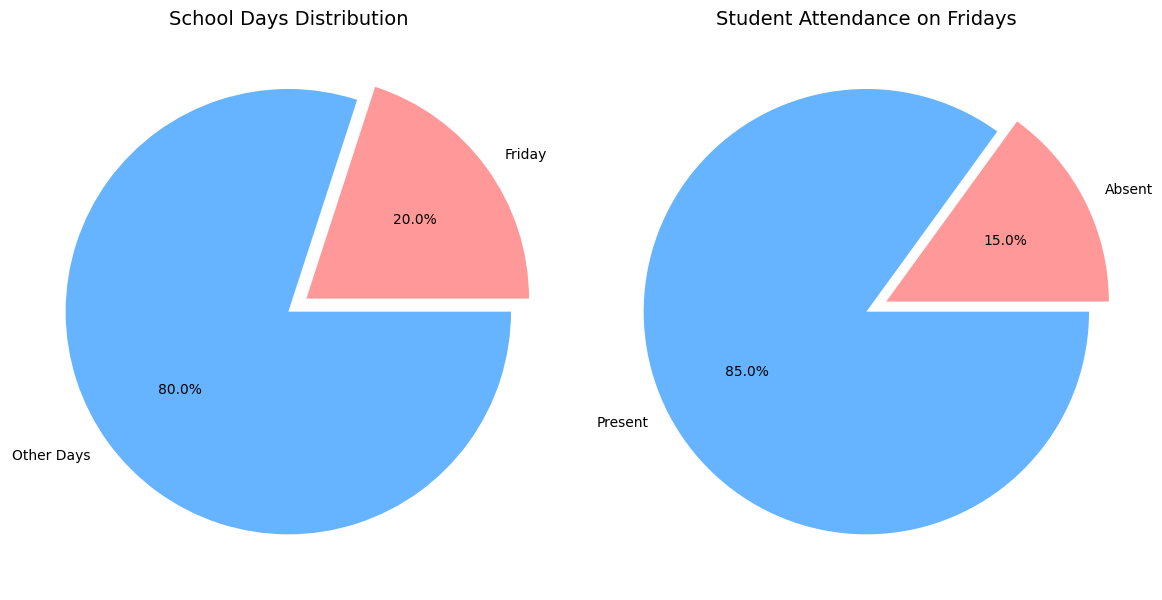

In [6]:
# Create more detailed data for visualization
friday_absent = p_friday_and_absent * total_students  # Students absent on Friday
friday_present = p_friday * total_students - friday_absent  # Students present on Friday
other_days = total_students * (1 - p_friday)  # Students on other days

# Create a pie chart showing Friday attendance
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.pie([p_friday, 1 - p_friday], 
        labels=['Friday', 'Other Days'], 
        autopct='%1.1f%%', 
        colors=['#ff9999', '#66b3ff'],
        explode=(0.1, 0))
plt.title('School Days Distribution', fontsize=14)

plt.subplot(1, 2, 2)
plt.pie([p_absent_given_friday, 1 - p_absent_given_friday], 
        labels=['Absent', 'Present'], 
        autopct='%1.1f%%', 
        colors=['#ff9999', '#66b3ff'],
        explode=(0.1, 0))
plt.title('Student Attendance on Fridays', fontsize=14)

plt.tight_layout()
plt.show()

## Simulating the Scenario

Let's create a simulation to verify our calculation.

In [7]:
# Set random seed for reproducibility
np.random.seed(42)

# Simulate a school year (180 days)
num_days = 180
num_students = 100

# Probability of a day being Friday
friday_prob = 0.2

# Probability of being absent given it's Friday (our answer)
absent_given_friday_prob = 0.15

# Probability of being absent given it's not Friday (we'll make this up)
absent_given_not_friday_prob = 0.05

# Generate random days (1 = Friday, 0 = not Friday)
days = np.random.choice([1, 0], size=num_days, p=[friday_prob, 1 - friday_prob])

# Initialize attendance records
attendance = np.zeros((num_days, num_students))

# Fill in attendance records (1 = present, 0 = absent)
for i in range(num_days):
    if days[i] == 1:  # If it's Friday
        attendance[i] = np.random.choice([1, 0], size=num_students, 
                                      p=[1 - absent_given_friday_prob, absent_given_friday_prob])
    else:  # If it's not Friday
        attendance[i] = np.random.choice([1, 0], size=num_students, 
                                      p=[1 - absent_given_not_friday_prob, absent_given_not_friday_prob])

# Calculate statistics from simulation
friday_indices = np.where(days == 1)[0]
friday_attendance = attendance[friday_indices]

# Count absences on Fridays
friday_absences = np.sum(friday_attendance == 0)
total_friday_records = friday_attendance.size

# Calculate simulated probability
simulated_prob = friday_absences / total_friday_records

print(f"Simulation results:")
print(f"Total days: {num_days}")
print(f"Total Fridays: {len(friday_indices)}")
print(f"Total student-days on Fridays: {total_friday_records}")
print(f"Total absences on Fridays: {friday_absences}")
print(f"Simulated P(Absent | Friday): {simulated_prob:.4f} or {simulated_prob * 100:.2f}%")
print(f"Theoretical P(Absent | Friday): {p_absent_given_friday:.4f} or {p_absent_given_friday * 100:.2f}%")

Simulation results:
Total days: 180
Total Fridays: 44
Total student-days on Fridays: 4400
Total absences on Fridays: 663
Simulated P(Absent | Friday): 0.1507 or 15.07%
Theoretical P(Absent | Friday): 0.1500 or 15.00%


## Interactive Visualization of Bayes' Rule

Let's create a function to visualize different scenarios of Bayes' rule.

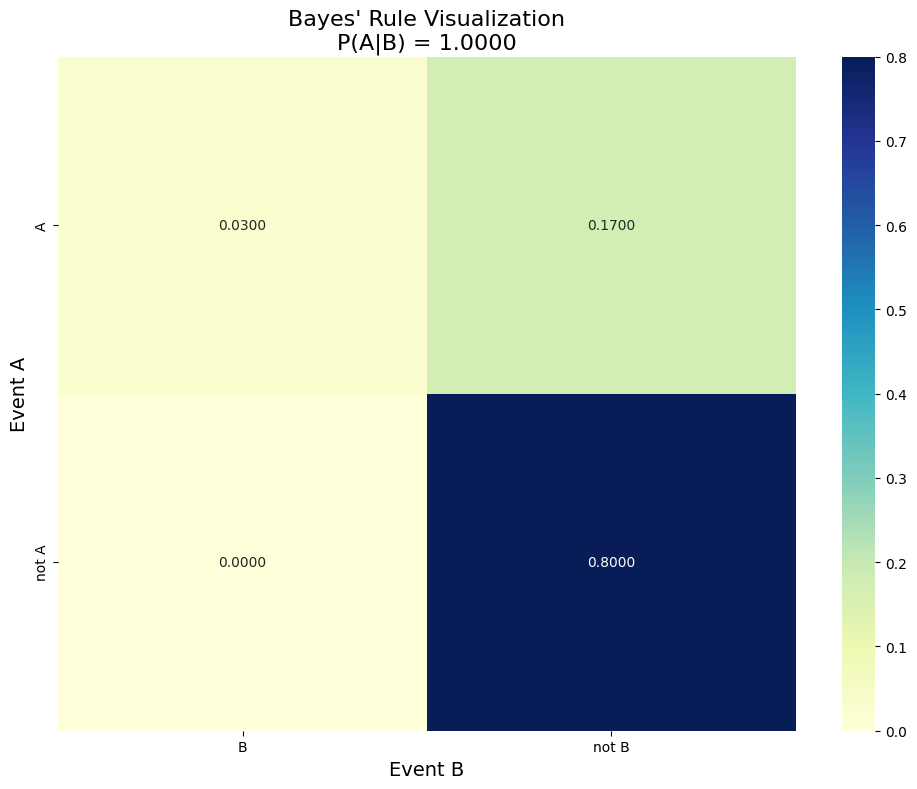

P(A) = 0.2000
P(B|A) = 0.1500
P(B|not A) = 0.0000
P(B) = 0.0300
P(A|B) = 1.0000


In [8]:
def visualize_bayes_rule(p_a, p_b_given_a, p_b_given_not_a):
    """
    Visualize Bayes' rule with given probabilities
    
    Parameters:
    - p_a: Probability of event A
    - p_b_given_a: Probability of event B given A
    - p_b_given_not_a: Probability of event B given not A
    """
    # Calculate other probabilities
    p_not_a = 1 - p_a
    p_b = p_b_given_a * p_a + p_b_given_not_a * p_not_a
    p_a_given_b = (p_b_given_a * p_a) / p_b
    
    # Create a 2x2 table
    data = np.zeros((2, 2))
    data[0, 0] = p_a * p_b_given_a  # P(A and B)
    data[0, 1] = p_a * (1 - p_b_given_a)  # P(A and not B)
    data[1, 0] = p_not_a * p_b_given_not_a  # P(not A and B)
    data[1, 1] = p_not_a * (1 - p_b_given_not_a)  # P(not A and not B)
    
    # Create a heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(data, annot=True, fmt='.4f', cmap='YlGnBu',
                xticklabels=['B', 'not B'],
                yticklabels=['A', 'not A'])
    plt.title(f"Bayes' Rule Visualization\nP(A|B) = {p_a_given_b:.4f}", fontsize=16)
    plt.xlabel('Event B', fontsize=14)
    plt.ylabel('Event A', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    print(f"P(A) = {p_a:.4f}")
    print(f"P(B|A) = {p_b_given_a:.4f}")
    print(f"P(B|not A) = {p_b_given_not_a:.4f}")
    print(f"P(B) = {p_b:.4f}")
    print(f"P(A|B) = {p_a_given_b:.4f}")

# Visualize our specific problem
# A = Friday, B = Absent

# For our problem:
# P(A) = P(Friday) = 0.2
# P(B|A) = P(Absent|Friday) = 0.15 (what we calculated)
# We need to estimate P(B|not A) = P(Absent|not Friday)

# Let's assume P(B|not A) to make P(A and B) = 0.03
p_a = 0.2  # P(Friday)
p_b_given_a = 0.15  # P(Absent|Friday) = 0.15 (our answer)

# Solve for P(B|not A) to make P(A and B) = 0.03
p_a_and_b = 0.03  # P(Friday and Absent)
p_b_given_not_a = (0.03 - p_a * p_b_given_a) / (1 - p_a)  # This is just a placeholder

# Visualize
visualize_bayes_rule(p_a, p_b_given_a, p_b_given_not_a)

## Conclusion

In this notebook, we've applied Bayes' rule to solve a specific probability problem:

> What is the probability that a student is absent given that today is Friday?

Given:
- $P(\text{Friday} \cap \text{Absent}) = 0.03$
- $P(\text{Friday}) = 0.20$

Using Bayes' rule, we calculated that:
- $P(\text{Absent} | \text{Friday}) = 0.15$ or 15%

We've visualized this result with bar charts, pie charts, and a simulation to confirm our calculations. This illustrates how Bayes' rule can be used to find conditional probabilities when given the joint probability and the probability of the condition.